In [ ]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

In [ ]:
# Load data
train = pd.read_csv('data/polynomial_train-1.csv')
x_train, y_train = train['X'].to_numpy(), train['Y'].to_numpy()

test = pd.read_csv('data/polynomial_test-1.csv')
x_test, y_test = test['X'].to_numpy(), test['Y'].to_numpy()

In [ ]:
# Transform data
degree = 6
X_train = np.array([x_train] * degree).T
X_test = np.array([x_test] * degree).T

# Create polynomial variables
for i in range(degree):
    X_train[:,i] = X_train[:,i] ** i
    X_test[:, i] = X_test[:, i] ** i

# Q4: Posterior Predictive

Write code to get the posterior predictive distribution
of the targets. Plot the posterior predictive distribution (mean and 95%
credible region) over the training data, along with the MLE and MAP. Do the
same plot again for the test data. Compare and contrast the results for the fully
Bayesian approach, the MAP, and the MLE. What effect does your prior have
on the posterior behavior?

In [ ]:
# Compute MLE betas
def fit_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.linalg.inv(X.T @ X) @ (X.T @ y)

betas = fit_ols(X_train, y_train)
y_pred_ols_train = X_train @ betas
y_pred_ols_test = X_test @ betas

# Smooth curve for plotting
x_curve = np.linspace(min(np.min(x_train), np.min(x_test)), max(np.max(x_train), np.max(x_test)), 200)
X_curve = np.column_stack([x_curve**i for i in range(degree)])
y_curve_ols = X_curve @ betas

In [ ]:
# Prior parameters
sigma = 1.0
w0 = np.zeros(degree)
sigma0 = 1.0

# Negative log-posterior (to minimize)
def neg_log_posterior(w: np.ndarray):
    residuals = y_train - X_train @ w
    log_likelihood = np.sum(norm.logpdf(residuals, loc=0, scale=sigma))
    log_prior = np.sum(norm.logpdf(w, loc=w0, scale=sigma0))
    return -(log_likelihood + log_prior)

result = minimize(neg_log_posterior, x0=np.zeros(degree))
betas_map = result.x

y_pred_map_train = X_train @ betas_map
y_pred_map_test = X_test @ betas_map

# Smooth curve for plotting
X_curve_map = np.column_stack([x_curve**i for i in range(degree)])
y_curve_map = X_curve_map @ betas_map

In [ ]:
# Priors
w_prior = np.zeros(degree)
tau = 1
Sigma_prior = tau**2 * np.eye(degree)

Sigma_n = np.linalg.inv(np.linalg.inv(Sigma_prior) + (1 / sigma**2) * (X_train.T @ X_train))
mu_n = Sigma_n @ (np.linalg.inv(Sigma_prior) @ w_prior + (1 / sigma**2) * (X_train.T @ y_train))

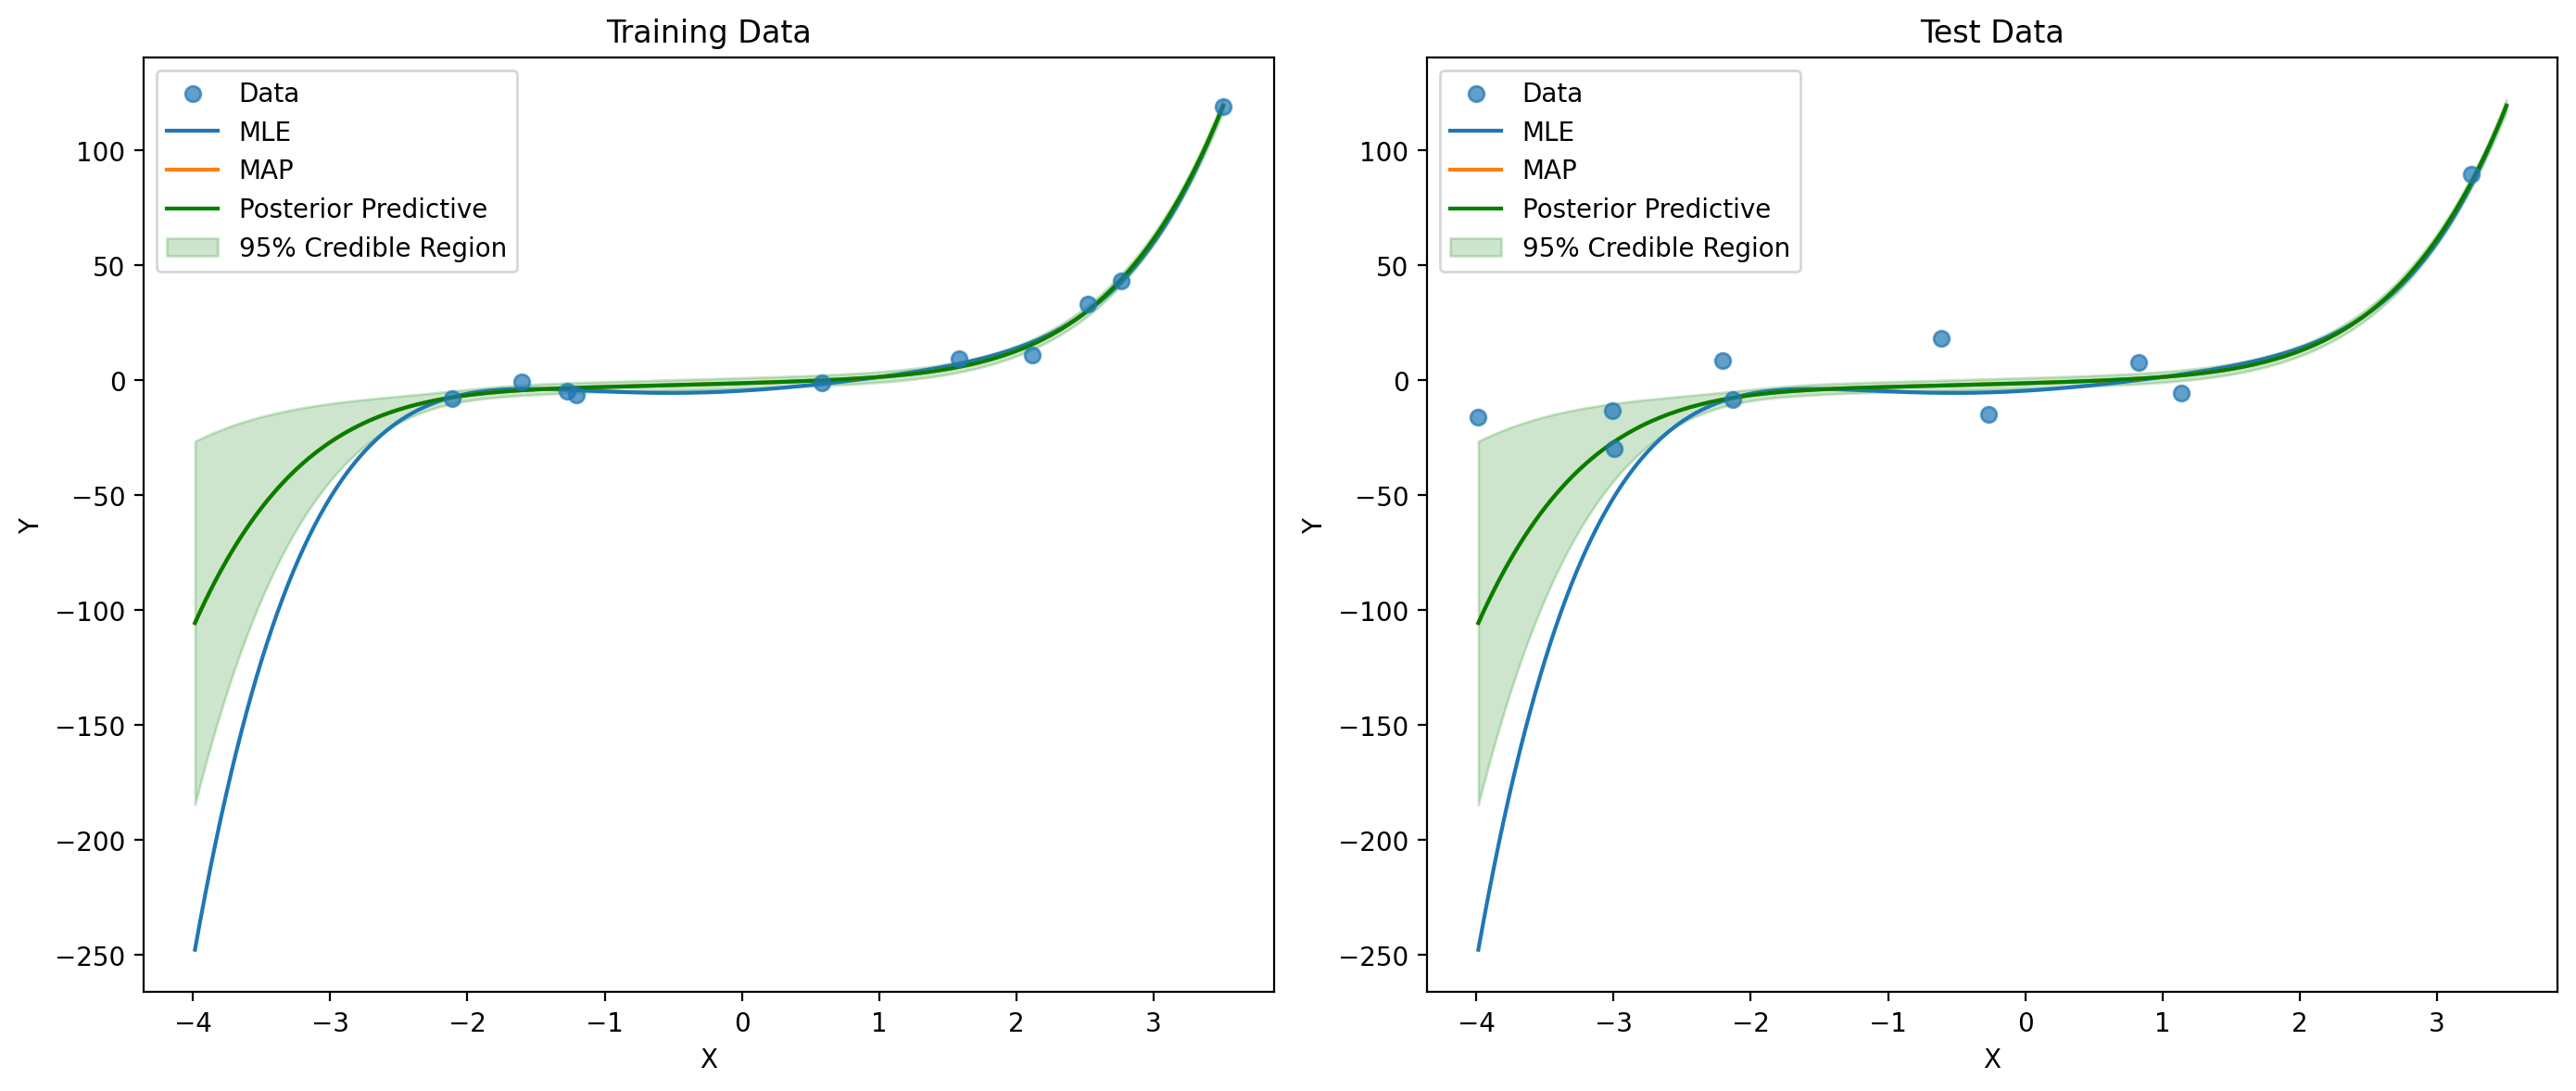

In [ ]:
# Posterior predictive over smooth curve
X_curve_pp = np.column_stack([x_curve**i for i in range(degree)])
y_pp_mean = X_curve_pp @ mu_n
y_pp_var = sigma**2 + np.diag(X_curve_pp @ Sigma_n @ X_curve_pp.T)
y_pp_std = np.sqrt(y_pp_var)

_, axes_pp = plt.subplots(1, 2, figsize=(14, 6))
for _ax, x_data, y_data, title in [
    (axes_pp[0], x_train, y_train, "Training Data"),
    (axes_pp[1], x_test, y_test, "Test Data"),
]:
    _ax.scatter(x_data, y_data, label="Data", alpha=0.7, zorder=3)
    _ax.plot(x_curve, y_curve_ols, label="MLE")
    _ax.plot(x_curve, y_curve_map, label="MAP")
    _ax.plot(x_curve, y_pp_mean, label="Posterior Predictive", color='green')
    _ax.fill_between(x_curve, y_pp_mean - 1.96 * y_pp_std, y_pp_mean + 1.96 * y_pp_std,
                    alpha=0.2, color='green', label="95% Credible Region")
    _ax.set_xlabel("X")
    _ax.set_ylabel("Y")
    _ax.set_title(title)
    _ax.legend()

plt.tight_layout()
plt.show()